# Aims of this notebook
Having read various papers about neural style transfer, three papers piqued my interest and thus in this notebook, I attempt to, firstly, evaluate the performance of AdaIN(Adaptive Instance Normalization) [[1]](https://arxiv.org/abs/1703.06868
) with Sliced Wasserstein Loss [[2]](https://openaccess.thecvf.com/content/CVPR2021/papers/Heitz_A_Sliced_Wasserstein_Loss_for_Neural_Texture_Synthesis_CVPR_2021_paper.pdf) and with Style-Aware Normalized Loss [[3]](https://arxiv.org/abs/2104.10064), with the artworks from wikiart.org. Secondly, I'll use this opportunity to have some fun by attempting to transfer styles from one anime to another.    

#Imports and preparing dataset

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.utils import save_image

In [ ]:
# print(torch.cuda.device_count())
# print(torch.cuda.get_device_name(0))

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
!unzip /content/NSt.zip

In [ ]:
#sample data

style_1 = Image.open('/content/NSt/style_1.jpg')
content_1 = Image.open('/content/NSt/content_1.jpg')
content_2 = Image.open('/content/NSt/content_2.jpg')
content_3 = Image.open('/content/NSt/content_3.jpg')

image_size = 256
transform = transforms.Compose(
    [
        transforms.PILToTensor() ,
        transforms.Resize((image_size, image_size)),
    ]
)

style_1_tensor = transform(style_1)
content_1_tensor = transform(content_1)
content_2_tensor = transform(content_2)
content_3_tensor = transform(content_3)

content_3_tensor.shape #Channel * Height * Width
content_3


#Classes

In [ ]:
class Encoder(nn.Module):
  def __init__(self):
    super(Encoder, self).__init__()

    self.chosen_layers = ['2', '9', '16', '29']
    self.vggmodel = models.vgg19(pretrained=True).features[:29].eval()
    self.module_list = nn.ModuleList()
    # self.modified_model = self.modified_model() #To add reflection padding and other layers
    # self.decoder = self.generate_decoder()

    for name, module in self.vggmodel.named_children():
      if isinstance(module, nn.Conv2d):
        # Add padding layer to the Sequential container
        self.module_list.append(nn.ReflectionPad2d(padding=1))
      # Add the original convolutional layer directly
      self.module_list.append(module)

    self.modules = nn.Sequential(*self.module_list)


    # for name,module in self.model.named_modules():
    # #Add reflection padding before conv layers
    #   if isinstance(module, nn.Conv2d):
    #     padding_layer = nn.ReflectionPad2d(padding=1)
    #     self.module_list.append(padding_layer)
    #   self.module_list.append(module)


  #Feature extraction of selected layers, basically functions as the encoder
  def forward(self,x):  #encoding process
    features = []
    if x.dtype != torch.float:
      x = x.float()
    for layer_num, layer in enumerate(self.module_list):
      if layer_num == 30:
        break

      x = layer(x)

      if str(layer_num) in self.chosen_layers:
        features.append(x)

    return features  #This list is accessible after passing thru the model, e.g. list = model(image)
                     #This represents the raw features after passing thru the layers


  def adain(self,content_features, style_features,batches=True,epsilon=1e-7):
    #features is the output from self.forward, shape is B*C*H*W or C*H*W
    epsilon = epsilon
    if len(content_features) != len(style_features):
        raise ValueError("Content and style features lists must have the same length.")

    # Calculate channel-wise mean and standard deviation
    encoded_features = []
    normalized_content_list = []
    normalized_style_list = []

    for content_feature, style_feature in zip(content_features, style_features):

      if content_feature.shape[0] != style_feature.shape[0]:
        raise ValueError("Content and style features in each pair must have the same number of channels.")

      if batches:
        content_mean = torch.mean(content_feature, dim=[2, 3], keepdim=True)
        content_std = torch.std(content_feature, dim=[2, 3], keepdim=True) + epsilon

        style_mean = torch.mean(style_feature, dim=[2, 3], keepdim=True)
        style_std = torch.std(style_feature, dim=[2, 3], keepdim=True) + epsilon

      else:
        content_mean = torch.mean(content_feature, dim=[1, 2], keepdim=True)
        content_std = torch.std(content_feature, dim=[1, 2], keepdim=True) + epsilon

        style_mean = torch.mean(style_feature, dim=[1, 2], keepdim=True)
        style_std = torch.std(style_feature, dim=[1, 2], keepdim=True) + epsilon

      # Normalize features
      normalized_content = (content_feature - content_mean) / content_std
      normalized_style = (style_feature - style_mean) / style_std
      normalized_content_list.append(normalized_content)
      normalized_style_list.append(normalized_style)

      encoded_feature = style_std * normalized_content + style_mean
      encoded_features.append(encoded_feature)

    return encoded_features,normalized_content_list,normalized_style_list
    #It is not a concern if the encoded_features have high values such as 800, especially
    #in the later layers the feature values gets multiplied by the filters and weights.






  # def generate_decoder(self):
  #   features = nn.ModuleList()
  #   for name, module in self.modified_model.named_modules()[::-1]:
  #     if isinstance(module, nn.MaxPool2d):
  #       features.append(nn.Upsample(scale_factor=2, mode='nearest'))
  #     else:
  #       features.append(module)

  #   return features




  #1)Calculate mean and s.d content and style features channel-wise, and normalize channel-wise
  #2)Apply style features scaling and shifting to content features
  def transform(self, content_features, style_features):
    for content_feature, style_feature in zip(content_features,style_features):
        pass



  #Get finalized image
  def decode(self,input):
    for layer in self.decoder:
      input = layer(input)

    return input

#MultiScaleDecoder
class Decoder(nn.Module):
  def __init__(self):
    super(Decoder, self).__init__()
    self.mse_loss = nn.MSELoss()
    self.resize = transforms.Resize((256,256))

    # 516 to 256 channels
    self.branch1 = nn.Sequential(nn.Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
                                 nn.ReflectionPad2d((1, 1, 1, 1)),
                                 nn.Upsample(scale_factor=2, mode='nearest'),
                                 nn.ReLU(inplace=True),
                                 nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
                                 nn.ReflectionPad2d((1, 1, 1, 1)),
                                 nn.ReLU(inplace=True),
                                 nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
                                 nn.ReflectionPad2d((1, 1, 1, 1)),
                                 nn.ReLU(inplace=True),
                                 nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
                                 nn.ReflectionPad2d((1, 1, 1, 1)),
                                 nn.ReLU(inplace=True),
                                 )
    #256 to 128
    self.branch2 = nn.Sequential(nn.Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
                                 nn.ReflectionPad2d((1, 1, 1, 1)),
                                 nn.Upsample(scale_factor=2, mode='nearest'),
                                 nn.ReLU(inplace=True),
                                 nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
                                 nn.ReflectionPad2d((1, 1, 1, 1)),
                                 nn.ReLU(inplace=True),
                                 )
    #128 to 64
    self.branch3 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
                                nn.ReflectionPad2d((1, 1, 1, 1)),
                                nn.Upsample(scale_factor=2, mode='nearest'),
                                nn.ReLU(inplace=True),
                                nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
                                nn.ReflectionPad2d((1, 1, 1, 1)),
                                nn.ReLU(inplace=True),
   )

    #64 to 3
    self.branch4 = nn.Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

    self.conv_final = nn.Conv2d(12, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    self.relu_final = nn.ReLU(inplace=True)


    # (0): ReflectionPad2d((1, 1, 1, 1))
    # (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    # (2): ReLU(inplace=True)
    # (3): ReflectionPad2d((1, 1, 1, 1))
    # (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    # (5): ReLU(inplace=True)
    # (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    # (7): ReflectionPad2d((1, 1, 1, 1))
    # (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    # (9): ReLU(inplace=True)
    # (10): ReflectionPad2d((1, 1, 1, 1))
    # (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    # (12): ReLU(inplace=True)
    # (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    # (14): ReflectionPad2d((1, 1, 1, 1))
    # (15): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    # (16): ReLU(inplace=True)
    # (17): ReflectionPad2d((1, 1, 1, 1))
    # (18): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    # (19): ReLU(inplace=True)
    # (20): ReflectionPad2d((1, 1, 1, 1))
    # (21): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    # (22): ReLU(inplace=True)
    # (23): ReflectionPad2d((1, 1, 1, 1))
    # (24): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    # (25): ReLU(inplace=True)
    # (26): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    # (27): ReflectionPad2d((1, 1, 1, 1))
    # (28): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

  # x is a list consisting of the below tensors
  # torch.Size([64, 258, 258])
  # torch.Size([128, 132, 132])
  # torch.Size([256, 69, 69])
  # torch.Size([512, 39, 39])


  def forward(self,x):
    final_conv = []
    for tensor in x:
      if len(tensor.shape) == 3:
        tensor = tensor.unsqueeze(0)
      if tensor.shape[1] == 512:
        tensor = self.branch1(tensor)
        tensor = self.branch2(tensor)
        tensor = self.branch3(tensor)
        tensor = self.branch4(tensor)
      elif tensor.shape[1] == 256:
        tensor = self.branch2(tensor)
        tensor = self.branch3(tensor)
        tensor = self.branch4(tensor)
      elif tensor.shape[1] == 128:
        tensor = self.branch3(tensor)
        tensor = self.branch4(tensor)
      elif tensor.shape[1] == 64:
        tensor = self.branch4(tensor)

      tensor = self.resize(tensor)
      final_conv.append(tensor) #concatenate?

    final_catted = torch.cat((final_conv),1)
    output = self.conv_final(final_catted)
    output = self.relu_final(output)

    return output
    #output is Bx3x256x256


    #Firstly, decoder is trained to turn the adain-transformed features into a picture
    #Secondly, the output of this decoder is passed through the 'frozen' encoder to get adain-ed features
    #Thirdly, this output is used to be compared with the adain-ed content and style for loss and backprop happens.

    #'content' is adain-ed output(modified_features), generated is output of this model forward-prop.
    #style_list and generated_list are lists of outputs from encoder(vgg net)
  def loss(self,generated,generated_list,content,style_list,style_loss_weight = 1,epsilon=1e-7,batches=False):
    content_loss = self.mse_loss(content,generated)

    #style loss is the sum of all layers, generated style image - referenced style image at each layer
    style_loss = 0
    for generated,style in zip(generated_list,style_list):
      if batches:
        style_mean = torch.mean(style, dim=[2, 3], keepdim=True)
        style_std = torch.std(style, dim=[2, 3], keepdim=True) + epsilon

        generated_mean = torch.mean(generated, dim=[2, 3], keepdim=True)
        generated_std = torch.std(generated, dim=[2, 3], keepdim=True) + epsilon

      else:
        style_mean = torch.mean(style, dim=[1, 2], keepdim=True)
        style_std = torch.std(style, dim=[1, 2], keepdim=True) + epsilon

        generated_mean = torch.mean(generated, dim=[1, 2], keepdim=True)
        generated_std = torch.std(generated, dim=[1, 2], keepdim=True) + epsilon

      mean_loss = self.mse_loss(generated_mean,style_mean)
      std_loss = self.mse_loss(generated_std,style_std)
      style_loss += mean_loss + std_loss

    total_loss = content_loss + style_loss
    return total_loss

      # for i in modified_features:
      #   print(i.shape)
      # torch.Size([64, 258, 258])
      # torch.Size([128, 132, 132])
      # torch.Size([256, 69, 69])
      # torch.Size([512, 39, 39])




    def backprop(self):
      pass




class StyleAware():
   def __init__(self):
    self.mse_loss = nn.MSELoss()

    def gram_matrix(self,feature):
      assert feature.dim() == 1
      C,H,W= feature.shape
      self.resize = self.transforms.Resize((C,H,W))
      resized_feature = self.resize(feature)
      return feature * torch.transpose(feature)

    def loss(self,target_list,generated_list): #AdaIN.get_style_features() outputs are passed through here
      assert len(target_list) == len(generated_list)

      losses = []
      for i in range(len(target_list)):
        #Spatial dimensions (PyTorch default: C*H*W )
        assert target.shape == generated.shape
        spatial_dim = target.shape[1] * target.shape[2]
        target = target_list[i]
        generated = generated_list[i]
        supremum = (self.mse_loss(target) + self.mse_loss(generated)) / spatial_dim



class SlicedWasserstein():
  def __init__(self):
    self.mse_loss = nn.MSELoss()

  def random_directions(self,dim=3,device='cpu'):
    directions = torch.randn(dim, 1).to(device)
    directions_unit_vector = directions / torch.sqrt(torch.sum(directions**2))

    return directions_unit_vector

  #F is the image features, F.shape = C*H*W and C == 3
  def loss(self, F, F_, directions=5):
    losses = []
    for i in range(directions):
      Vs = self.random_directions(dim=len(F.shape))

      # flatten pixel indices to [M,N]
      assert F.shape == F_.shape
      C, H, W = F.shape
      proj_flatten = torch.reshape(F,(C,H*W))
      proj_flatten = torch.transpose(proj_flatten)

      proj_flatten_ = torch.reshape(F_,(C,H*W))
      proj_flatten_ = torch.transpose(proj_flatten_)

      # project each pixel feature onto directions
      projection = torch.zeros_like(F)  #F.shape = (pixels x channels)
      for i in range(F.shape[0]): #1 x 3
        projection[i] = torch.dot(F[i], Vs)

      projection_ = torch.zeros_like(F_)
      for i in range(F_.shape[0]):
        projection_[i] = torch.dot(F_[i], Vs)

      # sort projections for each direction
      torch.sort(projection, axis=0)
      torch.sort(projection_, axis=0)

      losses.append(projection - projection_)

    return self.mse_loss(losses)



#Global functions
def load_image(tensor):
  transform = transforms.ToPILImage()
  image = transform(tensor)
  return image

def save_checkpoint(epoch, model, optimizer, filename="checkpoint.pth"):
  checkpoint = {
      'epoch': epoch,
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict()
  }
  torch.save(checkpoint, filename)



#Training

In [ ]:
enc = Encoder()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
content_features = enc(content_1_tensor)

In [ ]:
style_features = enc(style_1_tensor)

In [ ]:
modified_features,normalized_content,normalized_style = enc.adain(content_features, style_features, batches=False)

ModuleList(
  (0): ReflectionPad2d((1, 1, 1, 1))
  (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (2): ReflectionPad2d((1, 1, 1, 1))
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReflectionPad2d((1, 1, 1, 1))
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReflectionPad2d((1, 1, 1, 1))
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReflectionPad2d((1, 1, 1, 1))
  (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (10): ReflectionPad2d((1, 1, 1, 1))
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): ReflectionPad2d((1, 1, 1, 1))
  (13): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (14): ReflectionPad2d((1, 1, 1, 1))
  (15): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (16): ReflectionPad2d((1, 1, 1, 1))
  (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (18): ReflectionPad2d((1, 1, 1, 1))
  (19): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (20): ReflectionPad2d((1, 1, 1, 1))
  (21): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (22): ReflectionPad2d((1, 1, 1, 1))
  (23): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (24): ReflectionPad2d((1, 1, 1, 1))
  (25): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [ ]:
for i in modified_features:
  print(i.shape)

torch.Size([64, 258, 258])
torch.Size([128, 132, 132])
torch.Size([256, 69, 69])
torch.Size([512, 39, 39])


In [ ]:
decoder = Decoder()

In [ ]:
generate = decoder(modified_features)

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


In [ ]:
generate.shape

torch.Size([1, 3, 256, 256])

In [ ]:
generated_list = model(generate) #this will be the parameter for class Decoder, loss function.

In [ ]:
for i in generated_list:
  print(i.shape)

torch.Size([1, 64, 258, 258])
torch.Size([1, 128, 132, 132])
torch.Size([1, 256, 69, 69])
torch.Size([1, 512, 39, 39])


In [ ]:
generate[0].shape

torch.Size([3, 256, 256])

def loss(self,generated,generated_list,content,style_list,style_loss_weight = 1,epsilon=1e-7,batches=False):

In [ ]:
generated_list[-1][0].shape

torch.Size([512, 39, 39])

In [ ]:
loss = decoder.loss(generated_list[0][0],generated_list,modified_features[0],style_features)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([64, 1, 1])) that is different to the input size (torch.Size([1, 1, 1, 258])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([128, 1, 1])) that is different to the input size (torch.Size([1, 1, 1, 132])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([256, 1, 1])) that is different to the input size (torch.Size([1, 1, 1, 69])). This will likely lead to incorrect results due to broadcasting. Please ensure they have t

In [ ]:
loss

tensor(71187.1328, grad_fn=<AddBackward0>)

#Before training

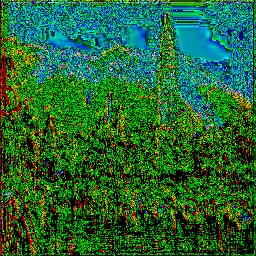

In [ ]:
img = load_image(dec[0])
img

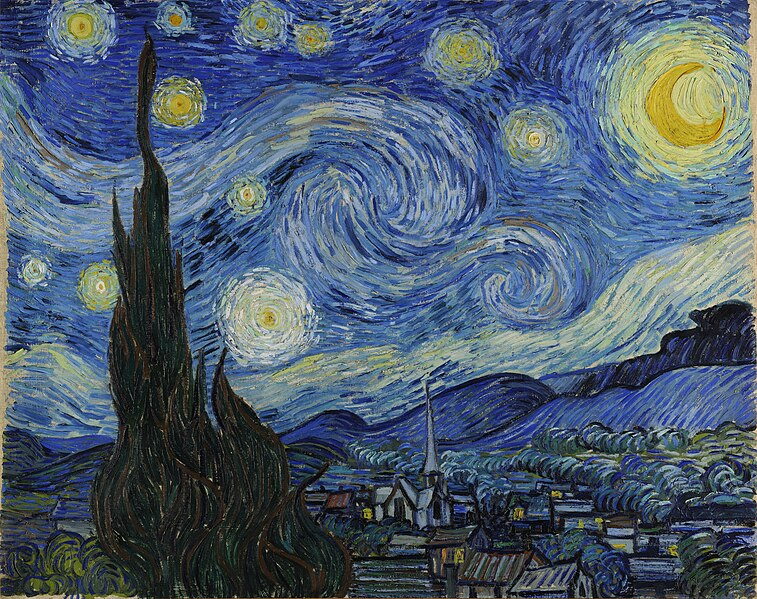

In [ ]:
style_1

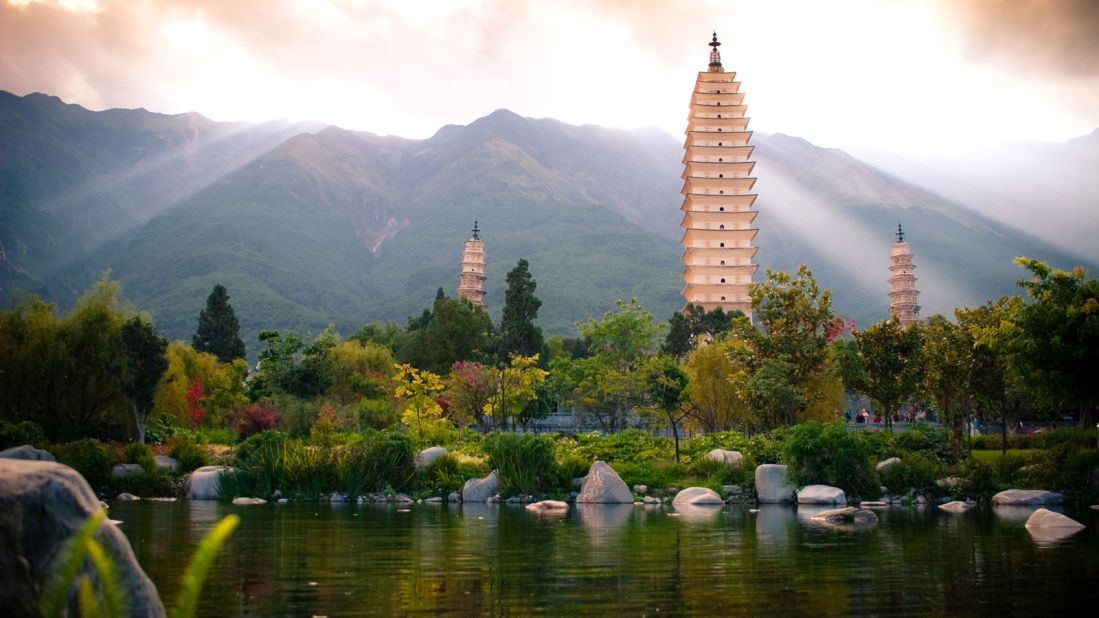

In [ ]:
content_1

#Training

In [ ]:
epochs = 5000
learning_rate = 0.001

model = nn.Sequential(Encoder(),Decoder())
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):

    # Backpropagation and parameter update
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    # Save parameters
    if (epoch + 1) % 10 == 0:
      save_checkpoint(epoch + 1, model, optimizer)


#mdamska

In [ ]:
#Training

# device = torch.device('cuda' if torch.cuda.is_available else 'cpu')

# generated1 = content_1.clone()
# generated2 = content_2.clone().requires_grad_(True)
# generated3 = content_3.clone().requires_grad_(True)


#Without decoder
model = VGG()
content_features = model(content_1_tensor) #Output is a list of features maps at targetted layers
style_features = model(style_1_tensor)

modified_features = model.encode(content_features, style_features, batches=False)
modified_features

# total_steps = 5000
# learning_rate = 0.001
# optimizer = optim.Adam([generated1], lr=learning_rate)

# for step in range(total_steps):
#   generated_features = model(generated1)  #Output is a list of features maps at targetted layers
#   original_img_features = model(content_1)
#   style_features = model(style_1)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


TODO

*   Get datasets, modify for batchsize in shape
*   Define losses, study SW loss
*   AdaIN decode (store the 'affine' params)
*   Pytorch Modules, integration
*   Other methods  



Daily:

SWD and AdaIN training


# Bibliography

[1] Xun Huang and Serge Belongie, Arbitrary Style Transfer in Real-time with Adaptive Instance Normalization , arxiv.org/abs/1703.06868

[2] Eric Heitz, Kenneth Vanhoey, Thomas Chambon and Laurent Belcour, A Sliced Wasserstein Loss for Neural Texture Synthesis, openaccess.thecvf.com/content/CVPR2021/papers/Heitz_A_Sliced_Wasserstein_Loss_for_Neural_Texture_Synthesis_CVPR_2021_paper.pdf

[3] Jiaxin Cheng, Ayush Jaiswal, Yue Wu, Pradeep Natarajan and Prem Natarajan, Style-Aware Normalized Loss for Improving Arbitrary Style Transfer, arxiv.org/abs/2104.10064